Raw shape: (398, 9)
After cleaning shape: (392, 8)

Data After Cleaning (head):
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model year  origin  
0          70       1  
1          70       1  
2          70       1  
3          70       1  
4          70       1  

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null   

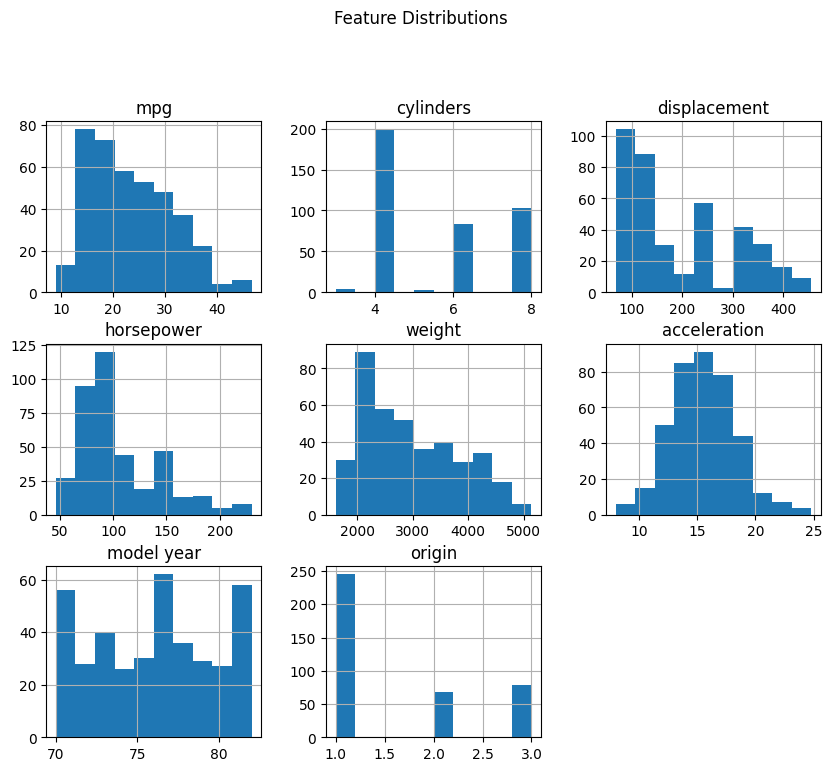

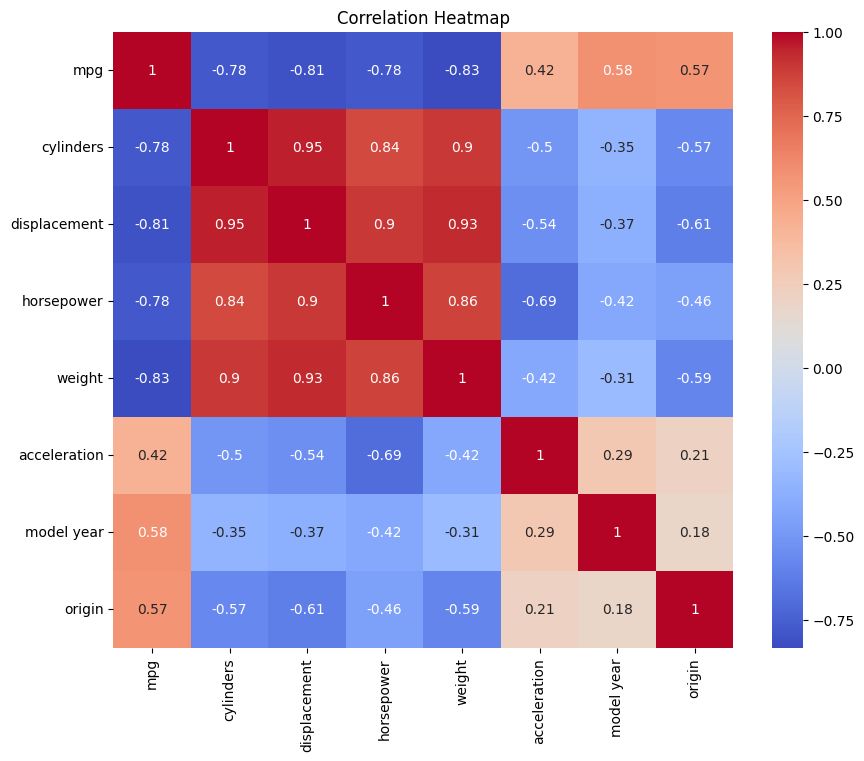

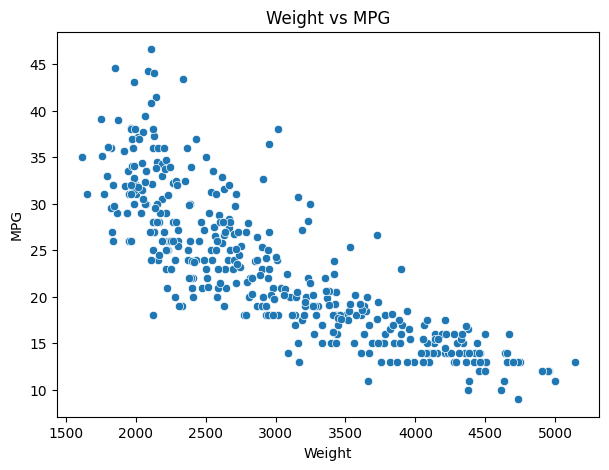

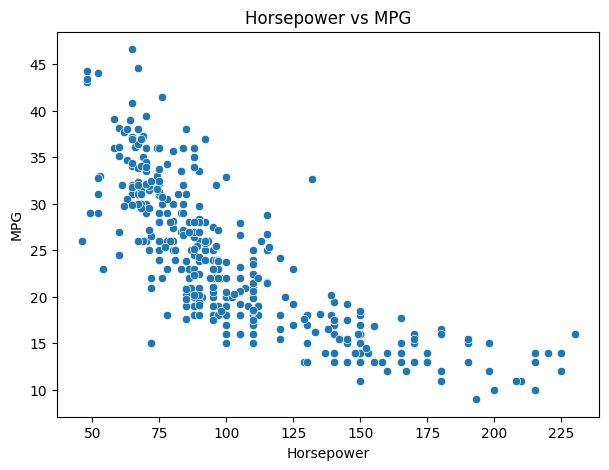


Features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
Target: mpg

--- Linear Regression (Test Set) ---
Linear Regression --> MAE: 2.420, RMSE: 3.273, R²: 0.790
Linear Regression Cross-Validation R² (mean): 0.5946212315010332


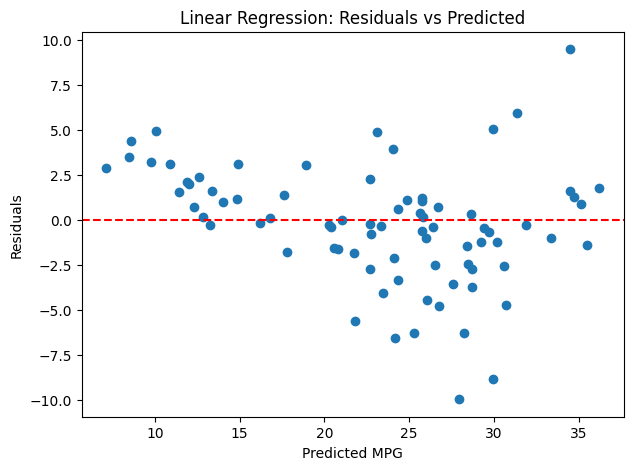

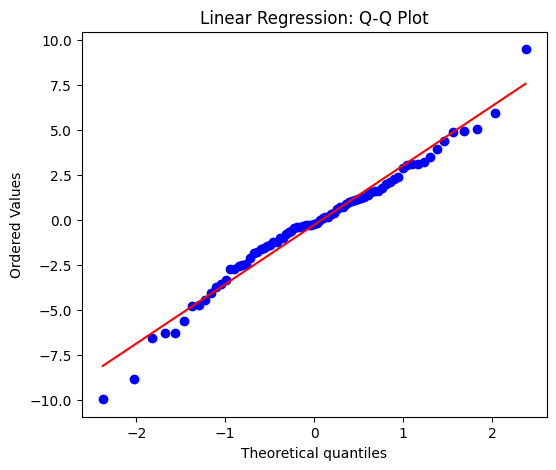


Linear Regression Coefficients:
        Feature  Coefficient
5    model year     2.782555
1  displacement     1.565273
6        origin     1.300240
4  acceleration     0.106767
0     cylinders    -0.587055
2    horsepower    -0.814205
3        weight    -5.157671
Intercept: 23.599361022364224

Best SVR Parameters: {'C': 10, 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}

--- SVR Best (GridSearch) (Test Set) ---
SVR Best (GridSearch) --> MAE: 1.782, RMSE: 2.388, R²: 0.888


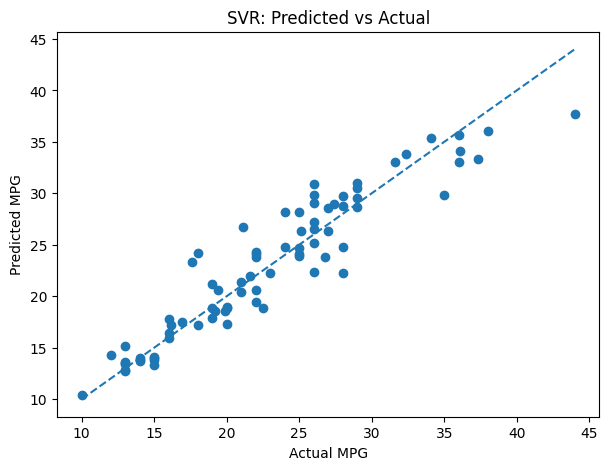


Comparison Table:
                   Model       MAE      RMSE        R2
0      Linear Regression  2.419780  3.272746  0.790150
1  SVR Best (GridSearch)  1.782063  2.387599  0.888312

Saved: best_svr_model.pkl + scaler.pkl

Created File: svr_predictions.csv


In [ ]:
# ==========================================
# MACHINE LEARNING PROJECT — FINAL VERSION
# Auto MPG: Linear Regression + SVR + GridSearch + Save Model
# Clean Pipeline + Proper CV + Plots + Export CSV
# ==========================================

# 1) Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import scipy.stats as stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ===============================
# 2) Load Data
# ===============================
df = pd.read_csv("auto-mpg.csv")
print("Raw shape:", df.shape)

# ===============================
# 3) Data Cleaning
# ===============================
# Replace "?" with NaN and convert to float
df["horsepower"] = df["horsepower"].replace("?", np.nan).astype(float)

# Drop missing rows
df.dropna(inplace=True)

# Drop text column
if "car name" in df.columns:
    df.drop(columns=["car name"], inplace=True)

print("After cleaning shape:", df.shape)
print("\nData After Cleaning (head):")
print(df.head())
print("\nInfo:")
df.info()


# ===============================
# 4) EDA (Exploratory Data Analysis)
# ===============================
# Histograms
df.hist(figsize=(10, 8))
plt.suptitle("Feature Distributions", y=1.02)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Scatter plots
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="weight", y="mpg")
plt.title("Weight vs MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="horsepower", y="mpg")
plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()


# ===============================
# 5) Features & Target
# ===============================
X = df.drop("mpg", axis=1)
y = df["mpg"]

print("\nFeatures:", list(X.columns))
print("Target: mpg")


# ===============================
# 6) Train / Test Split (BEFORE scaling)
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 7) Scaling (fit on train only)
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ===============================
# 8) Evaluation Function
# ===============================
def evaluate_model(y_true, y_pred, name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} --> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")
    return mae, rmse, r2


# ==========================================
# 9) Linear Regression
# ==========================================
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("\n--- Linear Regression (Test Set) ---")
lr_mae, lr_rmse, lr_r2 = evaluate_model(y_test, y_pred_lr, "Linear Regression")

# Cross Validation (Proper way using Pipeline to avoid leakage)
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
cv_scores = cross_val_score(lr_pipeline, X, y, cv=5, scoring="r2")
print("Linear Regression Cross-Validation R² (mean):", cv_scores.mean())

# Residual Plot (LR)
residuals_lr = y_test - y_pred_lr
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_lr, residuals_lr)
plt.axhline(0, color="red", linestyle="--")
plt.title("Linear Regression: Residuals vs Predicted")
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.show()

# Q-Q Plot (LR)
plt.figure(figsize=(6, 5))
stats.probplot(residuals_lr, dist="norm", plot=plt)
plt.title("Linear Regression: Q-Q Plot")
plt.show()

# Coefficients (LR)
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\nLinear Regression Coefficients:")
print(coef_df)
print("Intercept:", lr.intercept_)


# ==========================================
# 10) SVR + GridSearch
# ==========================================
param_grid = {
    "kernel": ["rbf", "poly"],
    "C": [1, 10, 100],
    "gamma": ["scale", "auto"],
    "degree": [2, 3, 4]   # used only if kernel='poly'
}

grid = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

best_svr = grid.best_estimator_
print("\nBest SVR Parameters:", grid.best_params_)

y_pred_svr = best_svr.predict(X_test_scaled)

print("\n--- SVR Best (GridSearch) (Test Set) ---")
svr_mae, svr_rmse, svr_r2 = evaluate_model(y_test, y_pred_svr, "SVR Best (GridSearch)")

# Predicted vs Actual (SVR)
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_svr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("SVR: Predicted vs Actual")
plt.show()


# ==========================================
# 11) Comparison Table (LR vs SVR)
# ==========================================
results = pd.DataFrame({
    "Model": ["Linear Regression", "SVR Best (GridSearch)"],
    "MAE": [lr_mae, svr_mae],
    "RMSE": [lr_rmse, svr_rmse],
    "R2": [lr_r2, svr_r2]
})
print("\nComparison Table:")
print(results)


# ==========================================
# 12) Save Best Model + Scaler
# ==========================================
with open("best_svr_model.pkl", "wb") as f:
    pickle.dump(best_svr, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("\nSaved: best_svr_model.pkl + scaler.pkl")


# ==========================================
# 13) Export Predictions to CSV
# ==========================================
pred_df = pd.DataFrame({
    "Actual MPG": y_test.values,
    "Predicted MPG (SVR)": y_pred_svr,
    "Residuals": y_test.values - y_pred_svr
})
pred_df.to_csv("svr_predictions.csv", index=False)

print("\nCreated File: svr_predictions.csv")


